In [1]:
import mujoco
import mediapy
import datetime
import numpy as np
import matplotlib.pyplot as plt

from typing import Callable
from math import ceil
from tqdm.notebook import tqdm
from recorder import Recorder

In [2]:
model = mujoco.MjModel.from_xml_path("../robot_models/cart_pole/scene.xml")
data = mujoco.MjData(model)

# avoid rendeder to be black-screened
try:
    renderer
except:
    renderer = mujoco.Renderer(model)

""

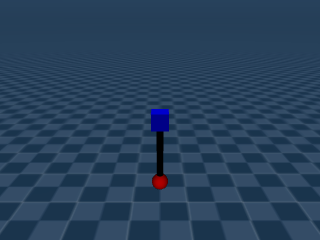

In [3]:
mujoco.mj_step(model, data)
renderer.update_scene(data)

mediapy.show_image(renderer.render())

In [4]:
def get_desc(
    amps: np.ndarray,
    freqs: np.ndarray,
    shifts: np.ndarray,
    is_sin: np.ndarray,
    amp_decimal: int,
    freq_decimal: int,
    shift_decimal: int,
) -> str:
    atoms = []
    for i, (is_sin_now, freq, amp, shift) in enumerate(zip(is_sin, freqs, amps, shifts)):
        func = "sin" if is_sin_now else "cos"
        amp = np.round(amp, amp_decimal)
        freq = np.round(freq, freq_decimal)
        shift = np.round(shift, shift_decimal)
        shift_str = ("+ " if shift >= 0 else "- ") + str(np.abs(shift))
        if i == 0 and amp <= 0:
            atoms.append("-")
        if i > 0:
            atoms.append(" + " if amp >= 0 else " - ")
        atoms.append(f"{np.abs(amp)} * {func}({freq} * t {shift_str})")
    return "".join(atoms)


def gen_ctrl(
    length: int,
    max_amp: float = 0.25,
    max_freq: float = 1,
    max_shift: float = 1,
    amp_decimal: int = 3,
    freq_decimal: int = 2,
    shift_decimal: int = 3,
) -> tuple[Callable[[float], float], str]:
    amps = np.round((np.random.rand(length) - 0.5) * max_amp * 2, decimals=amp_decimal)
    freqs = np.round(
        (np.random.rand(length) - 0.5) * max_freq * 2, decimals=freq_decimal
    )
    shifts = np.round(
        (np.random.rand(length) - 0.5) * max_shift * 2, decimals=shift_decimal
    )
    is_sin = np.random.randint(0, 2, size=length)

    def _ctrl(_t: float) -> float:
        res = 0.0
        for is_sin_now, freq, amp, shift in zip(is_sin, freqs, amps, shifts):
            res += (
                (amp * np.sin(freq * _t + shift))
                if is_sin_now
                else (amp * np.cos(freq * _t + shift))
            )
        return res

    return _ctrl, get_desc(amps, freqs, shifts, is_sin, amp_decimal, freq_decimal, shift_decimal)


np.random.seed(457)
ctrls_1 = []
ctrls_2 = []
ctrls_desc_1 = []
ctrls_desc_2 = []
N = 200

for i in range(N):
    ctrl_1, ctrl_1_desc = gen_ctrl(6, max_amp=0.4, max_freq=2)
    ctrl_2, ctrl_2_desc = gen_ctrl(6, max_amp=0.5, max_freq=3)
    ctrls_1.append(ctrl_1)
    ctrls_2.append(ctrl_2)
    ctrls_desc_1.append(ctrl_1_desc)
    ctrls_desc_2.append(ctrl_2_desc)

for ctrl_1_desc, ctrl_2_desc in zip(ctrls_desc_1, ctrls_desc_2):
    print("ctrl_1 =", ctrl_1_desc)
    print("ctrl_2 =", ctrl_2_desc)
    print()

ctrl_1 = -0.254 * sin(0.91 * t + 0.683) - 0.142 * cos(-1.65 * t + 0.52) - 0.294 * cos(1.85 * t - 0.812) + 0.039 * sin(-1.96 * t + 0.9) + 0.19 * sin(-1.82 * t + 0.584) - 0.319 * sin(0.65 * t - 0.989)
ctrl_2 = 0.306 * cos(0.67 * t - 0.704) - 0.335 * cos(-1.23 * t - 0.964) + 0.31 * sin(2.96 * t + 0.387) + 0.118 * sin(1.43 * t - 0.012) + 0.122 * sin(0.1 * t - 0.238) - 0.411 * cos(0.4 * t - 0.2)

ctrl_1 = -0.052 * cos(-1.54 * t + 0.014) + 0.258 * sin(1.32 * t - 0.889) - 0.124 * sin(0.83 * t - 0.559) - 0.072 * sin(1.39 * t - 0.481) - 0.124 * sin(-0.03 * t - 0.689) - 0.204 * sin(-1.0 * t - 0.952)
ctrl_2 = -0.252 * sin(-0.66 * t + 0.993) - 0.455 * cos(-0.95 * t + 0.678) - 0.279 * cos(0.5 * t + 0.376) - 0.084 * cos(0.8 * t - 0.975) + 0.173 * cos(1.88 * t + 0.42) + 0.233 * cos(0.35 * t + 0.16)

ctrl_1 = 0.134 * cos(1.43 * t - 0.796) + 0.166 * cos(-0.11 * t + 0.554) + 0.304 * sin(-1.26 * t - 0.491) + 0.241 * sin(-1.22 * t - 0.821) + 0.344 * sin(-1.66 * t + 0.693) + 0.256 * sin(1.44 * t - 0.984)
c

In [5]:
import os
from pathlib import Path
paths = list(Path("../data/raw/cart_pole/").iterdir())
for path in paths:
    os.remove(path)

In [6]:
np.random.seed(109)
duration = 2.5  # (seconds)
framerate = 30  # (Hz)
frames = []
rec = Recorder(model)
relax_steps = 3
relax_duration = 0.1


def bound_1(q: float, v: float):
    return -0.1 * q - 0.05 * v


def bound_2(q: float, v: float):
    return -0.2 * q - 0.05 * v


for ctrl_1, ctrl_2 in tqdm(list(zip(ctrls_1, ctrls_2))):
    rec = Recorder(model)
    n_steps = int(ceil(duration * framerate)) + 1
    target_path = (
        f"../data/raw/cart_pole/{datetime.datetime.now().strftime('%Y%m%d%H%M%S%f')}.csv"
    )
    relax_time = np.random.random(relax_steps) * (duration - relax_duration)
    relax_time = np.sort(np.r_[relax_time, relax_time + relax_duration])

    # Simulate and display video.
    frames = []
    mujoco.mj_resetData(model, data)  # Reset state and time.

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultCamera(cam)
    cam.lookat = np.array([0.0, 0.0, 1.0])
    cam.azimuth = -90
    cam.elevation = -20
    cam.distance = 1

    ctrl_on = True
    relax_idx = 0

    while data.time < duration:
        t = data.time
        q1, q2 = data.qpos
        v1, v2 = data.qvel

        if relax_idx < 2 * relax_steps and t >= relax_time[relax_idx]:
            ctrl_on = not ctrl_on
            relax_idx += 1

        if ctrl_on:
            data.ctrl[0] = ctrl_1(t) + bound_1(q1, v1)
            data.ctrl[1] = ctrl_2(t) + bound_2(q2, v2)
        else:
            data.ctrl[0] = 0.0
            data.ctrl[1] = 0.0

        cam.lookat = np.array([q1, 0, 1])
        mujoco.mj_checkPos(model, data)
        mujoco.mj_checkVel(model, data)
        mujoco.mj_forward(model, data)
        mujoco.mj_checkAcc(model, data)
        # record data
        rec.record(data)
        mujoco.mj_step(model, data)

        if len(frames) < data.time * framerate:
            renderer.update_scene(data, cam)
            pixels = renderer.render()
            frames.append(pixels)

    rec.save_df(target_path)

# Last video
mediapy.show_video(frames, fps=framerate)

  0%|          | 0/200 [00:00<?, ?it/s]

This browser does not support the video tag.


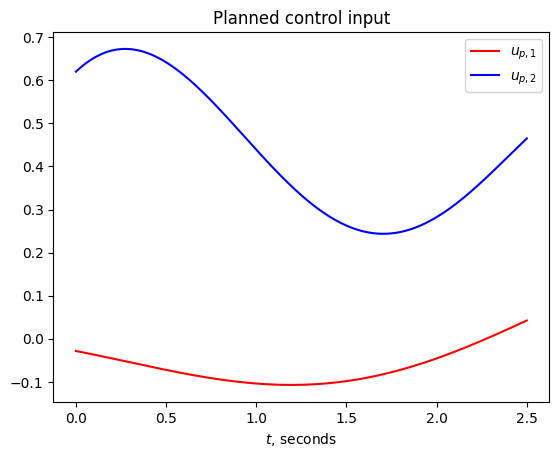

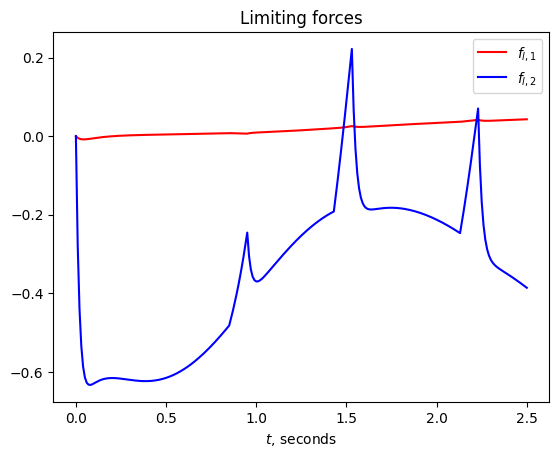

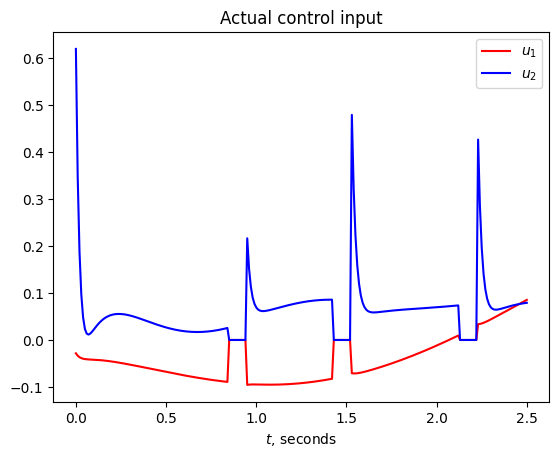

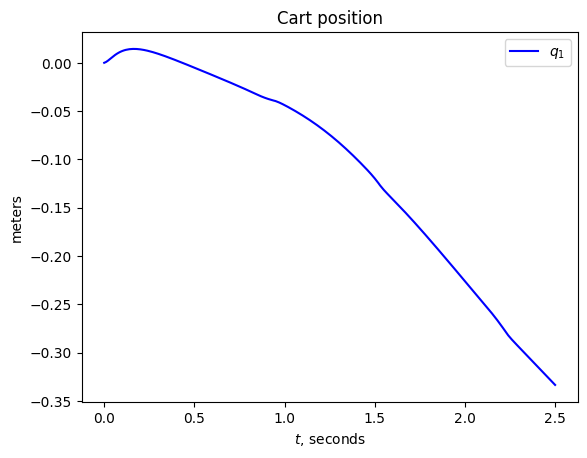

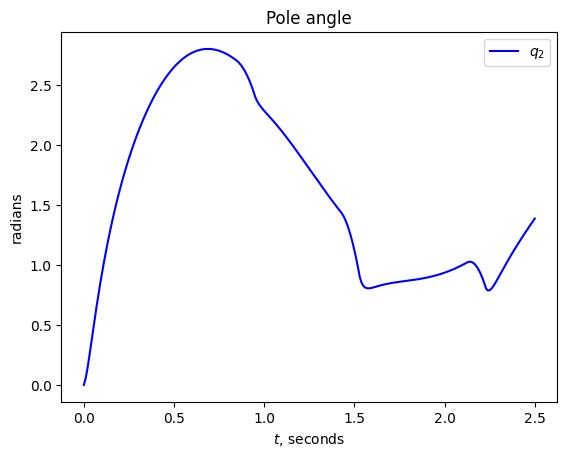

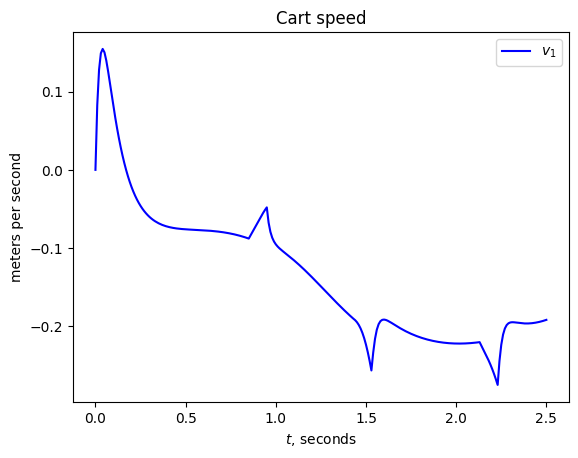

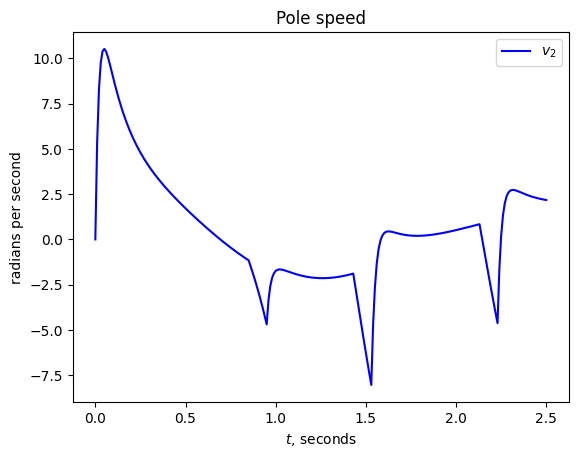

In [7]:
timespan = np.array(rec.history["time"])
ctrls = np.array(rec.history["ctrl"])
q_poses = np.array(rec.history["qpos"])
q_vels = np.array(rec.history["qvel"])

plt.title("Planned control input")
plt.plot(timespan, ctrl_1(timespan), color="red", label="$u_{p, 1}$")
plt.plot(timespan, ctrl_2(timespan), color="blue", label="$u_{p, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Limiting forces")
plt.plot(timespan, bound_1(q_poses[:, 0], q_vels[:, 0]), color="red", label="$f_{l, 1}$")
plt.plot(timespan, bound_2(q_poses[:, 1], q_vels[:, 1]), color="blue", label="$f_{l, 2}$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Actual control input")
plt.plot(timespan, ctrls[:, 0], color="red", label="$u_1$")
plt.plot(timespan, ctrls[:, 1], color="blue", label="$u_2$")
plt.legend(loc="best")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart position")
plt.plot(timespan, q_poses[:, 0], color="blue", label="$q_1$")
plt.legend(loc="best")
plt.ylabel("meters")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole angle")
plt.plot(timespan, q_poses[:, 1], color="blue", label="$q_2$")
plt.legend(loc="best")
plt.ylabel("radians")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Cart speed")
plt.plot(timespan, q_vels[:, 0], color="blue", label="$v_1$")
plt.legend(loc="best")
plt.ylabel("meters per second")
plt.xlabel("$t$, seconds")
plt.show()

plt.title("Pole speed")
plt.plot(timespan, q_vels[:, 1], color="blue", label="$v_2$")
plt.legend(loc="best")
plt.ylabel("radians per second")
plt.xlabel("$t$, seconds")
plt.show()